# Comaprison of Different Attribution Method 
## Attribution Experiment with the KNN Baseline

The KNN baseline learns the AI predictions shown during each participant-condition training phase and responds on held-out testing trials.

A compact end-to-end workflow for planning an XAI user study, training an AI model, generating explanations, previewing participant trials, and running a cognitive simulation.

## Workflow Outline

- Create the xaikit test object
- Define IVs, CVs, user task, and DVs
- Prepare the dataset
- Generate participant trials
- Train and evaluate the AI model
- Generate and visualize explanations
- Preview one participant's trials
- Configure the cognitive model
- Run and save simulation results


### Available methods

- Attribution:
    - LIME
    - SHAP (used for CoAX’s real and virtual studies)
    - Integrated gradients
    - Input gradients (used in CoAX's hypothesis generation simulations)
    - Layer-wise Relevance Propagation
    - Captum's DeepLift (Extended adapters)


## Setup


In [1]:
from pathlib import Path
import sys

import pandas as pd

repo_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "api.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.api as xk


## Create Workflow

Create one object to hold design, data, model, explanations, trials, and simulation outputs.


In [2]:
xaikitTest = xk.xaikitTest(
    project_name="xai_comparison_user_study",
    output_dir=".",
)


## Design Experiment

Define what changes across conditions, what metadata is tracked, what task users perform, and what outcomes are measured.


In [3]:
xaikitTest.guide("design")


Design guide
Goal: decide what XAI methods you want to test and how the study compares them.
IV: what you manipulate, e.g. `xai_method = ['shap', 'lime', 'none']`.
CV: trial/participant metadata you control or record, e.g. age group, gender, user_task.
DV: what you measure, e.g. `forward_accuracy`.
User task: what participants/cognitive agents do, e.g. `forward_simulation` means predict the AI output from the instance and explanation.
Typical call: add IVs, add CVs, add `user_task`, add DVs, then `validate(stage='design')`.


In [4]:
xaikitTest.add_iv(
    "xai_method",
    "between",
    ["shap", "lime", "lrp", "none"],
)

xaikitTest.add_iv(
    "tested_w_xai",
    "within",
    [True, False],
    randomization="trial",
)

xaikitTest.add_cv("user_task", ["forward_simulation"])

xaikitTest.add_dv("forward_accuracy", ["continuous"])

xaikitTest.validate(stage="design", show=True)


XAIKit validation: design

Normalized:
  IVs:
    xai_method: shap, lime, lrp, none
    tested_w_xai: True, False
  Semantic CVs:
    user_task: forward_simulation
  DVs: forward_accuracy
  CVs: user_task
  Context:
    dataset_id: not set
    model_name: not set
    model_source: not set
    cognitive_model_id: placeholder
    tasks: forward_simulation
    xai_methods: shap, lime, lrp, none
    xai_types: not set
    xai_faithfulness: not set
    dvs: forward_accuracy

## Prepare Dataset

Load a dataset and keep one stable split for training, trials, explanations, and display.


In [5]:
data = xaikitTest.prepare_dataset(
    "wine_quality",
    feature_cols=["Alcohol", "Sulphates", "SO2", "Vinegar Taint", "pH"],
    num_features=5,
    rank_features_by_target=True,
    test_size=0.2,
    random_state=42,
)

# Alternative example:
# data = xaikitTest.prepare_dataset("forest_cover", random_state=42)


Available training datasets: ['adult', 'breast_cancer', 'cardiotocography', 'forest_cover', 'heart_disease', 'king_county_housing', 'mushrooms', 'prima_diabetes', 'wine_quality']
Dataset   : wine_quality  (1599 rows, 5 model features)
Features  : ['Alcohol', 'Vinegar Taint', 'Sulphates', 'SO2', 'pH']
Encoding  : one-hot
Train set : 1279 samples  (80%)
Test set  : 320 samples  (20%)
Class balance (train) -> class 0: 1105
Class balance (train) -> class 1: 174
First test instanceIds: [434, 213, 1447, 231, 763, 1472, 472, 1327, 766, 19]


## Configure Trial Sampling

Set the participant and phase sizes now. Instances are sampled after AI training so training and testing can each be balanced 50/50 by the AI's predicted class.


In [6]:
trial_settings = {
    'participants_per_between_condition': 25,
    'num_training': 10,
    'num_testing': 20,
    'output_dir': 'experiment_output',
    'seed': 42,
    'preview_rows': 5,
}
trial_settings


{'participants_per_between_condition': 25,
 'num_training': 10,
 'num_testing': 20,
 'output_dir': 'experiment_output',
 'seed': 42,
 'preview_rows': 5}

## Train AI Model, Then Sample Balanced Trials

Call `xaikitTest.guide("training")` for the training arguments. Supported model types include `mlp`, `xgboost`, and `sim2real`.

The AI is trained before trial IDs are selected. Each participant then receives a randomized 50/50 mix of the AI's two predicted classes within training and within testing, while every training trial still precedes every testing trial.


In [7]:
xaikitTest.guide("training")


Model guide
Goal: train the AI model that later provides predictions and explanations.
Supported model types: `mlp`, `xgboost`, `sim2real`.
Key args: `model_type`, target metric/score, epoch limits, batch size.


In [8]:
model = xaikitTest.train_AI_model(
    model_type="mlp",
    target_metric="accuracy",
    target_score=0.90,
    max_epochs=1000,
    check_every_epochs=10,
    batch_size=100,
    verbose=False,
)

training_summary = xaikitTest.training_summary_table()
training_history = xaikitTest.training_history_table()

display(training_summary)
# display(training_history)

xaikitTest.validate(stage="trial_generation", show=True)
trial_result = xaikitTest.generate_trials(
    **trial_settings,
    balance_by_ai_prediction=True,
)
trial_table = pd.DataFrame(trial_result.trials)

assert (trial_table.groupby('participantId').head(10)['phase'] == 'training').all()
assert (trial_table.groupby('participantId').tail(20)['phase'] == 'testing').all()
assert trial_table.query("phase == 'training'")['tested_w_xai'].isna().all()
assert trial_table.query("phase == 'testing'")['tested_w_xai'].notna().all()

prediction_balance = (
    trial_table.groupby(['participantId', 'phase'])['sampled_ai_prediction']
    .value_counts()
    .rename('rows')
    .reset_index()
)
expected_per_class = {'training': 5, 'testing': 10}
assert prediction_balance.apply(
    lambda row: row['rows'] == expected_per_class[row['phase']], axis=1
).all()
display(prediction_balance.head(8))


,target_metric,target_score,final_score,epochs,batch_size,reached_target,target_accuracy,final_accuracy,model_type,dataset
0,accuracy,0.9,0.900704,130,100,True,0.9,0.900704,mlp,wine_quality


Counterbalancing strategy: complete_counterbalancing
Participant assignments: 100 total
Instance pool rows: 300
Trial rows: 3000
Exported trial artifacts:
  CSV     : experiment_output/trials.csv
  JSON    : experiment_output/trials.json
  Summary : experiment_output/design_summary.json

Previewing first 5 trial rows:
{'participantId': 1, 'trialId': 1, 'phase': 'training', 'phaseTrialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'dataId': 'wine_quality', 'instanceId': '430', 'sampled_ai_prediction': 1}
{'participantId': 1, 'trialId': 2, 'phase': 'training', 'phaseTrialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'dataId': 'wine_quality', 'instanceId': '1580', 'sampled_ai_prediction': 0}
{'participantId': 1, 'trialId': 3, 'phase': 'training', 'phaseTrialId': 3, 'block': 1, 'trialWithinBlock': 3, 'withinCondition': 'single_condition', 'xai_method': 'shap', 'dataId': 'wine_

,participantId,phase,sampled_ai_prediction,rows
0,1,testing,0,10
1,1,testing,1,10
2,1,training,0,5
3,1,training,1,5
4,2,testing,0,10
5,2,testing,1,10
6,2,training,0,5
7,2,training,1,5


## Evaluate AI Model

Review scalar metrics and the held-out test confusion matrix.


Test accuracy: 0.9156


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
train,0.900704,0.700426,0.732673,0.425287,0.538182,0.910995,0.636681,0.823892,0.700426,0.741277,0.890291,0.900704,0.889112
test,0.915625,0.725338,0.833333,0.465116,0.597015,0.861808,0.670138,0.877815,0.725338,0.774947,0.910343,0.915625,0.905060


,predicted_0,predicted_1
actual_0,273,4
actual_1,23,20


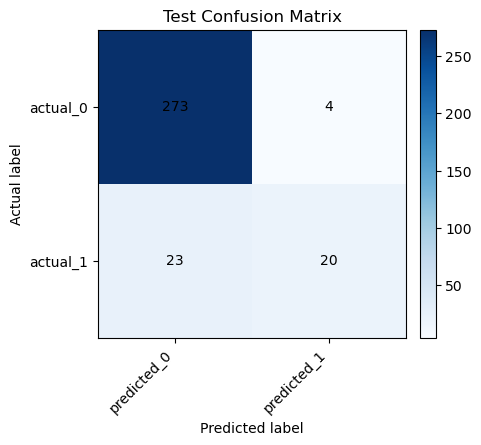

In [9]:
metrics = xaikitTest.evaluate(split="both", positive_label=1, threshold=0.5)
metrics_table = xaikitTest.metrics_table()

test_accuracy = xaikitTest.test_accuracy()
test_confusion_matrix = xaikitTest.confusion_matrix_table(split="test")

print(f"Test accuracy: {test_accuracy:.4f}")
display(metrics_table)
display(test_confusion_matrix)

ax = xaikitTest.plot_confusion_matrix(split="test")


## Generate Explanations

Generate explanation tables using the XAI methods already stored in the design.


In [10]:
xaikitTest.guide("xai")


Explanation guide
Goal: generate XAI tables for the methods stored in your design.
Default methods come from `xai_method`; default model name comes from training.
Key args: `target`, `output_dir`, optional method kwargs such as SHAP background size or LIME samples.


In [11]:
combined_path, combined_df = xaikitTest.explanations(
    output_dir="generated_explanation",
    target=1,
    method_kwargs={
        "shap": {"n_background_samples": 30},
        "shap_kernel": {"n_background_samples": 30},
        "lime": {"num_samples": 1000},
    },
)

all_dataset_ids = set(map(int, data.train_instance_ids)) | set(map(int, data.test_instance_ids))
assert set(xaikitTest.prediction_table['instanceId'].astype(int)) == all_dataset_ids

xai_visible_trials = trial_table[
    ~trial_table['xai_method'].astype(str).str.lower().isin(['none', 'no_xai', 'control'])
    & (
        trial_table['phase'].eq('training')
        | trial_table['tested_w_xai'].fillna(False).astype(bool)
    )
]
for method, method_trials in xai_visible_trials.groupby('xai_method'):
    expected_ids = set(method_trials['instanceId'].astype(int))
    generated_ids = set(
        combined_df.loc[combined_df['expMethod'].eq(method), 'instanceId'].astype(int)
    )
    assert generated_ids == expected_ids, f"Explanation coverage mismatch for {method}"

print(f"Complete prediction table: {xaikitTest.prediction_table_path}")
print(f"Combined explanation path: {combined_path}")
display(combined_df['expMethod'].value_counts().rename_axis('method').reset_index(name='rows'))
display(combined_df.query("expMethod != '__prediction_only__'").head())


Using stored XAI methods from the design: ['shap', 'lime', 'lrp', 'none']
Using stored model name for explanation files: 'mlp'

Generating explanations for xai method: shap
  Sampled instances: 310


  0%|          | 0/310 [00:00<?, ?it/s]

  Saved: generated_explanation/shap_mlp_wine_quality.csv shape=(310, 12)

Generating explanations for xai method: lime
  Sampled instances: 313
  Saved: generated_explanation/lime_mlp_wine_quality.csv shape=(313, 12)

Generating explanations for xai method: lrp
  Sampled instances: 306
  Saved: generated_explanation/lrp_mlp_wine_quality.csv shape=(306, 12)
Skipping explanation generation for xai method: none

Saved complete AI prediction table: generated_explanation/predictions_mlp_wine_quality.csv shape=(1599, 5)

Combined explanation CSV: generated_explanation/de_mlp_wine_quality.csv shape=(2528, 12)
Complete prediction table: generated_explanation/predictions_mlp_wine_quality.csv
Combined explanation path: generated_explanation/de_mlp_wine_quality.csv


/var/folders/96/n6tgn0rs16bfp1cm36gy56hh0000gn/T/ipykernel_76906/2392199993.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  | trial_table['tested_w_xai'].fillna(False).astype(bool)


,method,rows
0,__prediction_only__,1599
1,lime,313
2,shap,310
3,lrp,306


,dataId,modelName,expMethod,instanceId,pred,i_max,a0_i,a1_i,a2_i,a3_i,a4_i,intercept
1599,wine_quality,mlp,shap,430,1,0.162774,0.759972,0.938437,1.000000,0.286859,0.444491,0.14157
1600,wine_quality,mlp,shap,1580,0,0.150414,1.000000,0.210201,-0.468639,0.171428,-0.104851,0.14157
1601,wine_quality,mlp,shap,1554,0,0.061565,0.268424,-1.000000,-0.523432,0.294827,-0.572728,0.14157
1602,wine_quality,mlp,shap,898,1,0.310399,1.000000,0.173943,0.528078,-0.030405,0.051837,0.14157
1603,wine_quality,mlp,shap,1068,1,0.123011,0.819831,0.895403,1.000000,0.490297,0.706845,0.14157


### Visualize One Explanation

Use `visualization="importance"` for support toward the predicted class, or `visualization="influence"` for signed attribution.


(<Figure size 1050x435 with 5 Axes>,
 array([<AxesSubplot:title={'center':'Attribute'}>,
        <AxesSubplot:title={'center':'Value'}>, <AxesSubplot:>,
        <AxesSubplot:title={'center':'Importance'}>, <AxesSubplot:>],
       dtype=object))

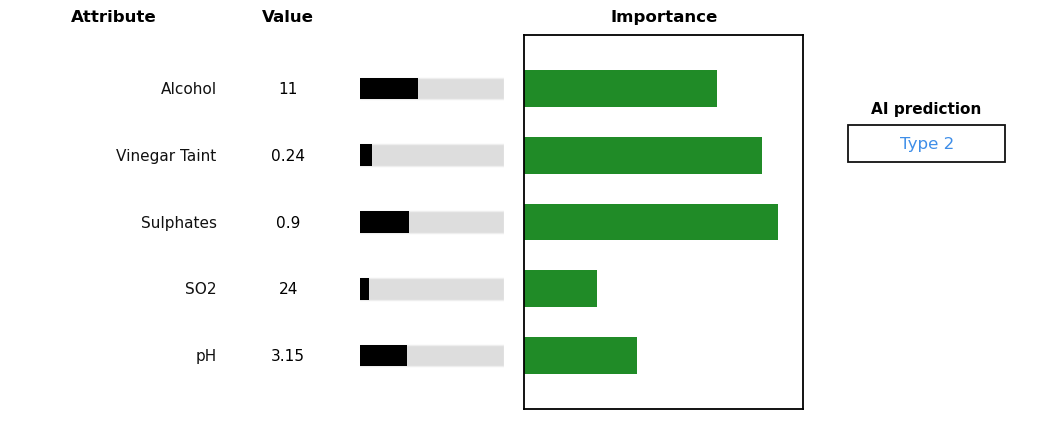

In [12]:
xaikitTest.plot_explanation(
    visualization="importance",
    method="shap",
    top_n=5,
    class_labels=["Type 1", "Type 2"],
)


## Preview Participant Trials

Browse one participant's instances one by one. Trials with XAI show the explanation; trials without XAI show the raw instance values.


In [ ]:
participant_trials = xaikitTest.preview_participant_trials(
    participant_id=1,
    visualization="importance",
    top_n=5,
    class_labels=["Type 1", "Type 2"],
    fallback="html",
)


## Configure Cognitive Model

Select the KNN baseline through the cognitive-model API. The executor fits a fresh copy for every participant-condition.


In [ ]:
xaikitTest.guide_cognitive_models()


In [ ]:
xaikitTest.set_cognitive_model(
    cognitive_model_id="knn",
    model_kwargs={"n_neighbors": 5},
)

xaikitTest.cognitive_params


## Run Simulation

Run the KNN baseline for every participant-condition, then save the responses.


In [ ]:
xaikitTest.validate(stage="execution", show=True)

simulated_results = xaikitTest.run_experiment(
    mode="whole_experiment",
    participant_id=None,
)

phase_summary = simulated_results.groupby('phase', as_index=False).agg(
    rows=('trialId', 'size'),
    responses=('agent_prediction', 'count'),
)
testing_responses = simulated_results.query("phase == 'testing'").copy()
display(phase_summary)
display(testing_responses[[
    'participantId', 'trialId', 'xai_method', 'tested_w_xai',
    'agent_prediction', 'ai_prediction', 'forward_accuracy',
]].head(10))


In [ ]:
sim_csv_path, sim_json_path = xaikitTest.save_results(
    out_dir="experiment_output",
)

print(f"Saved CSV : {sim_csv_path}")
print(f"Saved JSON: {sim_json_path}")

iv_dv_analysis = xaikitTest.analyze_iv_dv(
    iv="xai_method",
    dv="forward_accuracy",
)
display(iv_dv_analysis.descriptives)


## Plot every DV against every IV

The visualizer uses the `simulated_results` testing rows directly. Each subplot first averages repeated trials within participant and IV level, then plots the across-participant mean with SEM error bars.


In [ ]:
plot_ivs = list(xaikitTest.iv_config)
plot_dvs = list(xaikitTest.DVs)

result_grid = xaikitTest.plot_results_grid(
    responses=simulated_results,
    ivs=plot_ivs,
    dvs=plot_dvs,
    errorbar="sem",
    title="Virtual participant results",
)
print(f"Plotted {len(plot_dvs)} DV(s) × {len(plot_ivs)} IV(s)")
display(result_grid.summary)
result_grid.figure
